In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import logging
from spatialdata._logging import logger

logging.getLogger("fontTools").setLevel(logging.WARNING)
logging.getLogger("squidpy").setLevel(logging.WARNING)
logger.setLevel(logging.ERROR)

In [4]:
import scanpy as sc
import squidpy as sq
import decoupler as dc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [5]:
sc.settings.verbosity = 2
sc.settings.set_figure_params(frameon=False)
plt.rcParams["axes.grid"] = False

In [6]:
# set working directory
project_dir = "/home/cenk/Celik_enrichmap/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"

# processed data directory
processed_data = working_dir + "processed_data/"

# results directory
results_dir = working_dir + "results/"

In [7]:
adata = sq.datasets.visium_hne_adata()

In [8]:
adata.layers["counts"] = adata.raw.X.copy()
adata.X = adata.layers["counts"].copy()

#### Pyramidal layer

In [9]:
cell_type = "Pyramidal_layer"

In [10]:
adata.obs["group"] = np.where(
    adata.obs["cluster"] == cell_type, cell_type, "Rest"
)

In [11]:
# Create pseudo-replicates
# Randomly assign spots to k pseudo-replicates within each group.
# More splits = more power but noisier aggregates. k=3–5 is typical.
k = 3
rng = np.random.default_rng(0)

rep_labels = []
for grp in [cell_type, "Rest"]:
    mask = adata.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, k, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata.obs_names[mask],
        )
    )
adata.obs["pseudo_rep"] = pd.concat(rep_labels)

In [12]:
# Aggregate raw counts per pseudo-replicate
counts_mat = adata.raw.X if adata.raw is not None else adata.X

# densify if sparse
if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata.obs_names,
    columns=(adata.raw.var_names if adata.raw is not None else adata.var_names),
)
counts_df["pseudo_rep"] = adata.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

In [13]:
# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

In [14]:
# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

In [15]:
dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

In [16]:
dds.deseq2()

stat = DeseqStats(dds, contrast=["group", cell_type, "Rest"])
stat.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 2.34 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 1.89 seconds.

Fitting LFCs...
... done in 2.45 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Pyramidal_layer vs Rest
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Xkr4             13.990780       -0.083120  0.578804  -0.143607  8.858106e-01   
Sox17            16.623469       -0.563613  0.562099  -1.002694  3.160083e-01   
Mrpl15          230.222003        0.311663  0.132390   2.354124  1.856639e-02   
Lypla1           97.864240       -0.408573  0.223575  -1.827455  6.763139e-02   
Tcea1           270.422112        0.141140  0.125261   1.126766  2.598413e-01   
...                    ...             ...       ...        ...           ...   
Spry3            27.247020        0.295910  0.379984   0.778743  4.361311e-01   
Tmlhe             4.572914        0.445387  0.879734   0.506274  6.126641e-01   
AC149090.1      661.028193        0.783338  0.076088  10.295133  7.411690e-25   
CAAA01118383.1   45.610506       -0.158145  0.312466  -0.506119  6.127734e-01   
CAAA01147332.1    3.720653        1.29092

... done in 1.70 seconds.



In [17]:
results = stat.results_df.copy()

In [18]:
# Filter for upregulated genes in Pyramidal_layer
up = results[
    (results["padj"] < 0.01)
    & (results["log2FoldChange"] > 1)
].sort_values("log2FoldChange", ascending=False)

print(f"Upregulated genes in {cell_type}: {len(up)}")
print(up.head(10))

Upregulated genes in Pyramidal_layer: 624
                 baseMean  log2FoldChange     lfcSE       stat         pvalue  \
Lefty1         314.356587        5.410233  0.133247  40.602982   0.000000e+00   
6330420H09Rik   30.772507        5.346630  0.402306  13.289966   2.646987e-40   
B230110G15Rik   18.160693        5.207354  0.516693  10.078228   6.895868e-24   
Fgf16           13.514214        5.124792  0.559049   9.166983   4.864431e-20   
Fibcd1         703.834385        5.079793  0.205064  24.771757  1.807417e-135   
4921539H07Rik   39.945966        4.933498  0.339606  14.527131   8.156598e-48   
Spink8         793.624772        4.841077  0.097796  49.501665   0.000000e+00   
Efcab6         144.390704        4.530357  0.174433  25.971938  1.027909e-148   
Tmprss6         23.330919        4.441136  0.780839   5.687643   1.288046e-08   
Gm2115         364.640932        4.393603  0.106076  41.419348   0.000000e+00   

                        padj  
Lefty1          0.000000e+00  
6330

In [19]:
# Save results
up.to_csv(results_dir + f"{cell_type}_vs_Rest_deseq2_results.csv", index=True)

6 [0.76336719 0.9392477 ]
8 [ 0.54667804 -0.29594477]


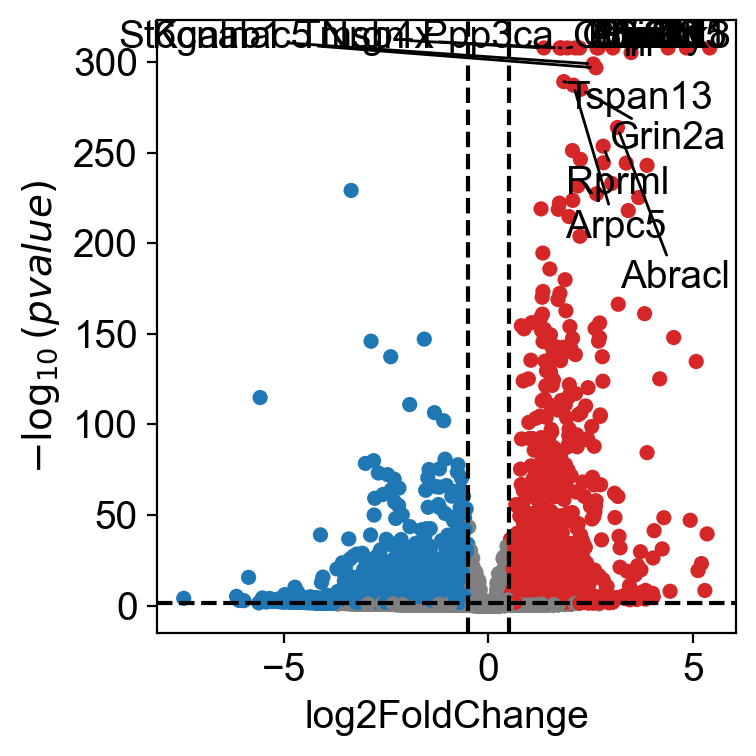

In [20]:
dc.pl.volcano(
    results,
    x="log2FoldChange",
    y="pvalue",
    figsize=(4, 4),
    top=20,
    save=figure_dir + f"visium_degs_{cell_type}_volcano.pdf",
)

In [21]:
# Build the dictionary
top_ns = [2, 5, 10, 20, 50, 100, 200, 500]
signatures = {
    f"{cell_type}_top{n}": up.index[:n].tolist() for n in top_ns if n <= len(up)
}

# Save
with open(f"{cell_type}_signatures.pkl", "wb") as f:
    pickle.dump(signatures, f)

#### Cortex

In [22]:
cell_type = "Striatum"

In [23]:
adata.obs["group"] = np.where(adata.obs["cluster"] == cell_type, cell_type, "Rest")

In [24]:
# Create pseudo-replicates
# Randomly assign spots to k pseudo-replicates within each group.
# More splits = more power but noisier aggregates. k=3–5 is typical.
k = 3
rng = np.random.default_rng(0)

rep_labels = []
for grp in [cell_type, "Rest"]:
    mask = adata.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, k, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata.obs_names[mask],
        )
    )
adata.obs["pseudo_rep"] = pd.concat(rep_labels)

In [25]:
# Aggregate raw counts per pseudo-replicate
counts_mat = adata.raw.X if adata.raw is not None else adata.X

# densify if sparse
if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata.obs_names,
    columns=(adata.raw.var_names if adata.raw is not None else adata.var_names),
)
counts_df["pseudo_rep"] = adata.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

In [26]:
# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

In [27]:
# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

In [28]:
dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

In [29]:
dds.deseq2()

stat = DeseqStats(dds, contrast=["group", cell_type, "Rest"])
stat.summary()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.09 seconds.

Fitting dispersion trend curve...
... done in 0.32 seconds.

Fitting MAP dispersions...
... done in 1.96 seconds.

Fitting LFCs...
... done in 2.40 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.89 seconds.



Log2 fold change & Wald test p-value: group Striatum vs Rest
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4             21.280769       -0.125340  0.382880 -0.327362  0.743394   
Sox17            33.097332        0.228594  0.293356  0.779238  0.435840   
Mrpl15          331.926715        0.052037  0.104656  0.497216  0.619037   
Lypla1          156.603218       -0.461587  0.148327 -3.111957  0.001859   
Tcea1           439.194796        0.208613  0.082160  2.539103  0.011114   
...                    ...             ...       ...       ...       ...   
Spry3            44.968128        0.460056  0.245577  1.873370  0.061017   
Tmlhe             5.286553       -1.007825  0.898514 -1.121657  0.262008   
AC149090.1      856.428455        0.269111  0.062388  4.313476  0.000016   
CAAA01118383.1   80.361821        0.177447  0.188970  0.939021  0.347720   
CAAA01147332.1    3.493589       -0.176540  0.939590 -0.187890  0.850963   

                    padj  

In [30]:
results = stat.results_df.copy()

In [31]:
# Filter for upregulated genes in Striatum
up = results[
    (results["padj"] < 0.05)
    & (results["log2FoldChange"] > 1)
].sort_values("log2FoldChange", ascending=False)

print(f"Upregulated genes in {cell_type}: {len(up)}")
print(up.head(10))

Upregulated genes in Striatum: 434
                  baseMean  log2FoldChange     lfcSE       stat  \
Ucn3             20.044354        6.082456  0.689597   8.820300   
Cyp19a1          11.805529        5.086949  0.669431   7.598916   
Adora2a         289.841149        4.868117  0.170384  28.571379   
Ccdc42           50.266187        4.390997  0.295541  14.857512   
Ido1             39.179033        4.328071  0.315642  13.711951   
Sstr5            23.602958        4.157183  0.400814  10.371851   
Chrna10          17.135790        4.060143  0.459749   8.831207   
Gm48485          11.796488        3.917722  0.547974   7.149463   
6430628N08Rik    29.732730        3.913659  0.350633  11.161682   
Penk           3362.926084        3.873956  0.080539  48.100492   

                      pvalue           padj  
Ucn3            1.141537e-18   3.509119e-17  
Cyp19a1         2.986224e-14   6.740078e-13  
Adora2a        1.524201e-179  1.636556e-176  
Ccdc42          6.219264e-50   6.359727e-48

In [32]:
up.to_csv(results_dir + f"{cell_type}_vs_Rest_deseq2_results.csv", index=True)

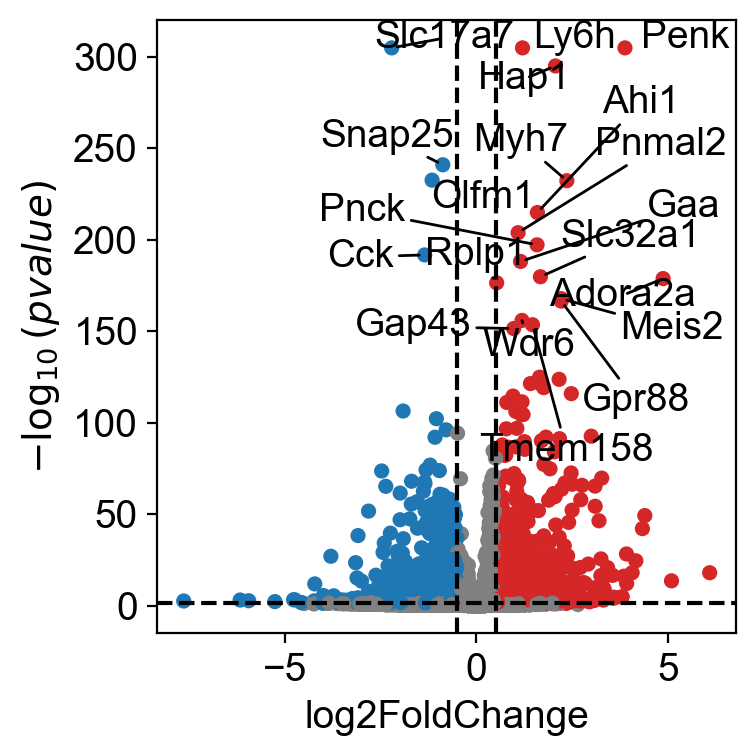

In [33]:
dc.pl.volcano(
    results,
    x="log2FoldChange",
    y="pvalue",
    figsize=(4, 4),
    top=20,
    save=figure_dir + "visium_degs_volcano_dentate.pdf",
)

In [34]:
# Build the dictionary
top_ns = [2, 5, 10, 20, 50, 100, 200, 434]
signatures = {f"{cell_type}_top{n}": up.index[:n].tolist() for n in top_ns if n <= len(up)}

# Save
with open(f"{cell_type}_signatures.pkl", "wb") as f:
    pickle.dump(signatures, f)